Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pynwb
import h5py
import remfile

from dandi.dandiapi import DandiAPIClient


print('pynwb  :', pynwb.__version__)
print('h5py   :', h5py.__version__)
print('remfile:', remfile.__version__)

pynwb  : 4.0.0
h5py   : 3.16.0
remfile: 0.1.13


Stream Dandiset

In [39]:
from dandi.dandiapi import DandiAPIClient

DANDISET_ID = '000021'   # Allen Visual Coding · Neuropixels (ratón)

with DandiAPIClient() as client:
    dandiset = client.get_dandiset(DANDISET_ID, 'draft')
    meta = dandiset.get_raw_metadata()
    print('Nombre :', meta.get('name'))
    print('Version:', dandiset.version_id)

    # Listamos unos pocos assets (ficheros) para ver la convención de nombres
    print('\nPrimeros ficheros del dandiset:')
    for i, asset in enumerate(dandiset.get_assets()):
        print(f'  {asset.path}   ({asset.size/1e9:.2f} GB)')
        if i >= 8:
            print('  ...')
            break

Nombre : Allen Institute - Visual Coding - Neuropixels (Brain Observatory 1.1 Stimulus Set)
Version: draft

Primeros ficheros del dandiset:
  sub-699733573/sub-699733573_ses-715093703_probe-810755797_ecephys.nwb   (2.06 GB)
  sub-699733573/sub-699733573_ses-715093703_probe-810755799_ecephys.nwb   (2.47 GB)
  sub-699733573/sub-699733573_ses-715093703_probe-810755801_ecephys.nwb   (2.25 GB)
  sub-699733573/sub-699733573_ses-715093703_probe-810755803_ecephys.nwb   (2.30 GB)
  sub-699733573/sub-699733573_ses-715093703.nwb   (2.86 GB)
  sub-699733573/sub-699733573_ses-715093703_probe-810755807_ecephys.nwb   (1.30 GB)
  sub-699733573/sub-699733573_ses-715093703_probe-810755805_ecephys.nwb   (2.46 GB)
  sub-703279277/sub-703279277_ses-719161530_probe-729445654_ecephys.nwb   (0.07 GB)
  sub-703279277/sub-703279277_ses-719161530.nwb   (3.07 GB)
  ...


In [40]:
dandiset_id = "000021"  # Allen Visual Coding · Neuropixels (ratón)
dandi_filepath = "sub-738651046/sub-738651046_ses-760693773.nwb"

with DandiAPIClient() as client:
    dandiset = client.get_dandiset(dandiset_id, 'draft')
    asset = dandiset.get_asset_by_path(dandi_filepath)
    s3_url = asset.get_content_url(follow_redirects=1, strip_query=True)

print('Asset :', asset.path)
print('URL   :', s3_url)

Asset : sub-738651046/sub-738651046_ses-760693773.nwb
URL   : https://dandiarchive.s3.amazonaws.com/blobs/4dd/fc6/4ddfc61e-7c06-47d0-9057-f53d70943cd3


In [41]:
# Patrón de streaming recomendado por DANDI
rem_file = remfile.File(s3_url)
h5_file  = h5py.File(rem_file, 'r')
io       = pynwb.NWBHDF5IO(file=h5_file, load_namespaces=True)
nwb      = io.read()

nwb   # en Jupyter, esto muestra un resumen navegable del NWBFile

Data type,float32
Shape,"(550800,)"
Array size,2.10 MiB
Chunk shape,None
Compression,None
Compression opts,None
Uncompressed size (bytes),2203200
Compressed size (bytes),2203200
Compression ratio,1.0
Data type,float64
Shape,"(550800,)"


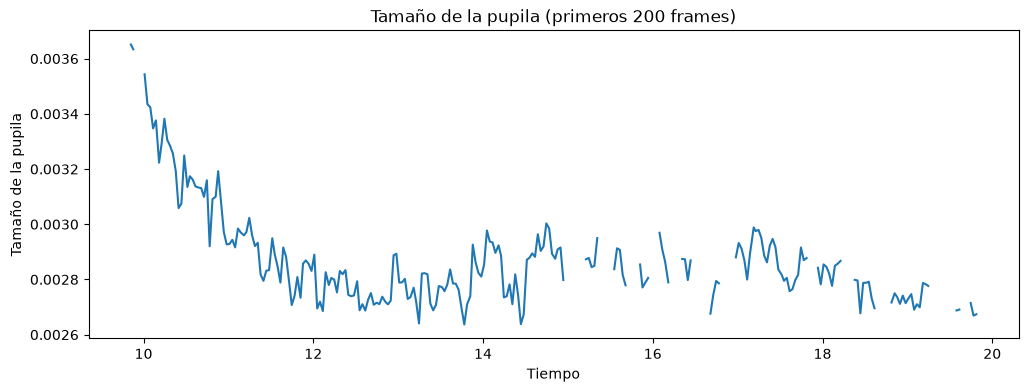

In [ ]:
# Access pupil_tracking timeseries

pupil_area = nwb.processing['filtered_gaze_mapping']['pupil_area'].data[200:500] #.pupil_tracking.data.size # en Jupyter, esto muestra un resumen navegable del TimeSeries
time_pupil = nwb.processing['filtered_gaze_mapping']['pupil_area'].timestamps[200:500]

# pupil_left = nwb.processing['filtered_gaze_mapping'].pupil_tracking.data[:200, 0]
# pupil_right = nwb.processing['filtered_gaze_mapping'].pupil_tracking.data[:200, 1]

plt.figure(figsize=(12, 4))
plt.plot(time_pupil, pupil_area)
plt.title('Tamaño de la pupila (primeros 200 frames)')
plt.xlabel('Tiempo')
plt.ylabel('Tamaño de la pupila')
plt.show()


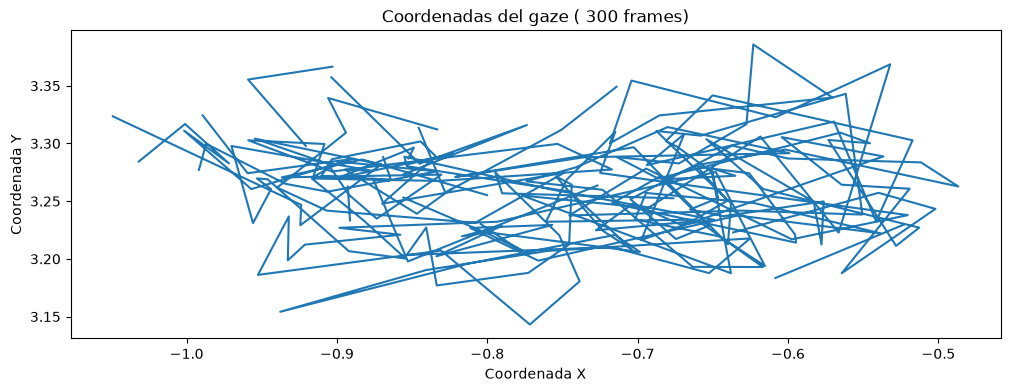

In [60]:
# Access pupil_tracking timeseries

x_gaze =nwb.processing['filtered_gaze_mapping']['screen_coordinates'].data[200:500, 0]  #.pupil_tracking.data.size # en Jupyter, esto muestra un resumen navegable del TimeSeries
y_gaze =nwb.processing['filtered_gaze_mapping']['screen_coordinates'].data[200:500, 1]  #.pupil_tracking.data.size # en Jupyter, esto muestra un resumen navegable del TimeSeries
time_gaze = nwb.processing['filtered_gaze_mapping']['screen_coordinates'].timestamps[200:500]

# pupil_left = nwb.processing['filtered_gaze_mapping'].pupil_tracking.data[:200, 0]
# pupil_right = nwb.processing['filtered_gaze_mapping'].pupil_tracking.data[:200, 1]

plt.figure(figsize=(12, 4))
plt.plot(x_gaze, y_gaze)
plt.title('Coordenadas del gaze ( 300 frames)')
plt.xlabel('Coordenada X')
plt.ylabel('Coordenada Y')

plt.show()


NaN antes: 45469 | NaN despues: 0


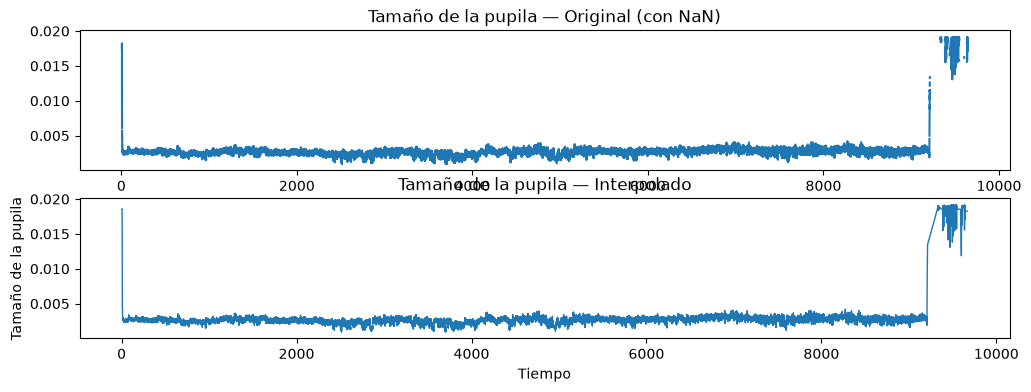

In [66]:
# Interpolar los NaN de pupil_area con numpy
pupil_ts   = nwb.processing['filtered_gaze_mapping']['pupil_area']
pupil_area = pupil_ts.data[:].astype(float)
time_pupil = pupil_ts.timestamps[:]

nan_mask = np.isnan(pupil_area)
valid    = ~nan_mask

pupil_area_interp = pupil_area.copy()
pupil_area_interp[nan_mask] = np.interp(time_pupil[nan_mask], time_pupil[valid], pupil_area[valid])

print(f'NaN antes: {nan_mask.sum()} | NaN despues: {np.isnan(pupil_area_interp).sum()}')

# Grafico comparativo
sl = slice(500, 800)
plt.figure(figsize=(12, 4))
plt.subplot(2, 1, 1)
# plt.plot(time_pupil[sl], pupil_area[sl], '-', ms=3, label='Original (con NaN)')
plt.plot(time_pupil, pupil_area, '-', ms=3, label='Original (con NaN)')
plt.title('Tamaño de la pupila — Original (con NaN)')
plt.subplot(2, 1, 2)
# plt.plot(time_pupil[sl], pupil_area_interp[sl], '-', lw=1, label='Interpolado')
plt.plot(time_pupil, pupil_area_interp, '-', lw=1, label='Interpolado')
plt.title('Tamaño de la pupila — Interpolado')
plt.xlabel('Tiempo')
plt.ylabel('Tamaño de la pupila')
# plt.legend()
plt.show()


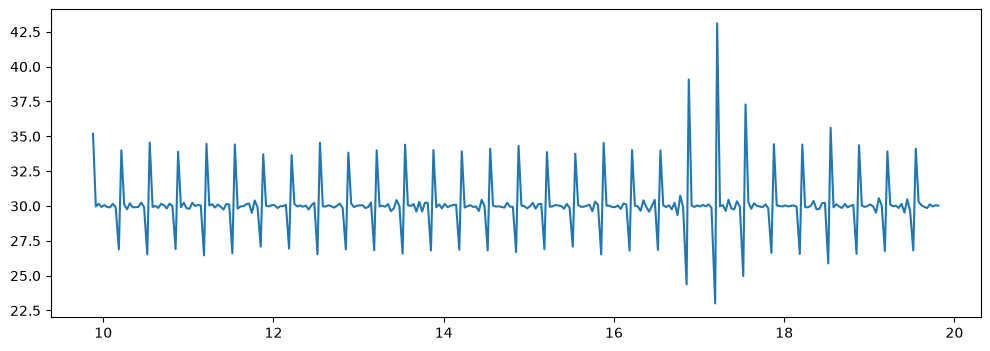

In [68]:
fs = time[1:] - time[:-1]

plt.figure(figsize=(12, 4))
plt.plot(time[1:], 1/fs)